# Introduction

Our task was to determine the best neighborhood in Pittsburgh. Using the WPRDC datasets, we determined three sub-metrics.
- Air quality
- Number of schools
- Number of arrests
  
Our main metric is the wellbeing of the citizens of the people who live in these neighborhoods. We came up with this metric because it maximizes the definition of "good" by being a vague term. Wellbeing can consist of having a good education, having a good mental/physical health, and feeling safe. These three datasets hit all of these marks.
- Air quality = Physical health
- Number of schools = Mental health (being involved in a school community can build a good state of mind) and amount of education available
- Number of arrests = Feeling safe

These three datasets will help shape the wellbeing of the citizens in these neighborhoods and will help determine which is the best one.

# The Metric

## Air quality
To measure air quality, it is based off of an index. The best index, "good," is air quality that is measured from an index of 0-50 with 0 being the best as there is no dangerous pollution in the air, so we are measuring the air quality index value to determine the neighborhood with the best air quality. This data set from WPRDC (https://data.wprdc.org/dataset/allegheny-county-air-quality/resource/4ab1e23f-3262-4bd3-adbf-f72f0119108b) measures daily air quality from different sites. The neighborhood that has the most amount of times where an air quality index of 0 is recorded is determined to be the best neighborhood for this sub-metric because it is the most consistent with the perfect air quality.

After doing the above, the winner of this sub-metric is...
### Bedford Dwellings!
with a total amount of 1238 times a perfect air quality index of 0 was recorded. :)

## Arrest rate
I decided to measure arrest rate in each neighborhood because I think safety is an important factor when choosing the best neighborhood. I gathered all the police arrest data (https://data.wprdc.org/datastore/dump/e03a89dd-134a-4ee8-a2bd-62c40aeebc6f) and found which neightborhoods had the most/least arrests. From these findings,
### Central Business District had the most number of arrests while Mt. Oliver had the least!

### School enrollment
To measure education, we used enrollment data from the Pittsburgh Public Schools Enrollment dataset, (https://data.wprdc.org/dataset/pittsburgh-public-schools-enrollment/resource/cbf270fd-891e-49bb-98fb-d6d52c260847
). This dataset included the number of K-12 students living in each neighborhood in Pittsburgh and attending public schools. We used the total amount of students enrolled in our metric because higher enrollment typically reflects stronger educational access and more active school communities giving more oppertunities for families in that neighborhood. The neighborhood with the strongest educational presence was, 

### Carrick!
with 1276 students making it the neighborhood with the greatest education levels. 

# The Best Neighborhood

Unfortunately, our datasets clashed with each other and we didn't have a clear conclusion on which neighborhood was really "the best." However, Lawrenceville scores a moderate level of air quality and number of arrests. While it isn't the best for air quality, it's level is still good. While the number of arrests isn't completely at its lowest, it's a moderately safe neighborhood. For number of schools, there's no record if Lawrenceville is the best in having a large amount of schools, but it's not the lowest amount either, so it has a moderate amount. Therefore, combining all of our sub-metrics into one metric of measuring the wellbeing of the citizens, we believe Lawrenceville is the best Pittsburgh neighborhood to live in.

# Conclusions

## Lan:
This is my first time living in Pittsburgh so I don't have a clear opinion on what my favorite neighborhood is, but so far, I'd say my favorite is Squirrel Hill. I love going to Squirrel Hill because there are so many things to do and eat there and it's always really lively. It's also a very walkable neighborhood which I like. However, these metrics of entertainment and walkability aren't included in our metric (wellbeing) so it's not surprising to see why we chose Lawrenceville over Squirrel Hill (different metrics!). If we went off of my personal metrics, I'm sure Squirrel Hill would've won. But, I'm not surprised Lawrenceville won either. It seems like a pretty good neighborhood that's moderately safe, moderately balancing mental and physical health states, and has a decent amount of schools.
## Kat:
I would say my favorite neighborhood in Pittsburgh is the Strip District. Theres so much to do there and I just love going with friends on a weekend. Its fun to just walk around a window shop at all the stores! Theres also a lot of resturants to stop at if you want to grab a bite to eat!
## Yasmin:

Since I haven’t explored many Pittsburgh neighborhoods yet as someone coming from out of state, my personal favorites are based on limited experience. My criteria is more about atmosphere and things to do, while our metric was grounded in public data. I’ve enjoyed Squirrel Hill the most so far, but the reasons I like it, such as the food and atmosphere, aren’t part of the well-being metrics we measured. Our well-being metric was based on education, air quality, and safety, not the food, walkability, or atmosphere that matter to me in choosing a favorite neighborhood. Because of that, it makes sense that the data-driven “best neighborhood” ended up being different from the one I prefer personally.

# The Data

## Air quality

In [3]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

OK! Now we can use pandas to analyze the dataset, numpy to calculate mathematical computations, and matplotlib to create plots! And a bit of "magic" as well... Now, let's read our dataset.

In [4]:
aq = pd.read_csv("airquality.csv") # Load dataset
aq.head(79332) # Display all the rows

,_id,date,site,parameter,index_value,description,health_advisory,health_effects
0,1,2016-01-01,Lawrenceville,PM25B,25,Good,NaN,NaN
1,2,2016-01-01,Flag Plaza,CO,0,Good,NaN,NaN
2,3,2016-01-01,Harrison Township,OZONE,31,Good,NaN,NaN
3,4,2016-01-01,Avalon,SO2,10,Good,NaN,NaN
4,5,2016-01-01,Lincoln,PM25,35,Good,NaN,NaN
...,...,...,...,...,...,...,...,...
79327,95324,2025-11-02,Pittsburgh,PM25_640,53,Moderate,Unusually sensitive people should consider red...,Respiratory symptoms possible in unusually sen...
79328,95325,2025-11-02,South Fayette,PM25_640,34,Good,NaN,NaN
79329,95326,2025-11-02,Lawrenceville 2,SO2,11,Good,NaN,NaN
79330,95327,2025-11-02,Liberty,SO2,4,Good,NaN,NaN


Let's ignore id, date, and parameter. We want to focus on index value and which neighborhood the air quality is recorded in. 0-50 is a sign of good air quality. Let's focus on the data we need.

In [5]:
df = aq[['site', 'index_value']] # Sort dataset by only site and index value
df.head(79332)

,site,index_value
0,Lawrenceville,25
1,Flag Plaza,0
2,Harrison Township,31
3,Avalon,10
4,Lincoln,35
...,...,...
79327,Pittsburgh,53
79328,South Fayette,34
79329,Lawrenceville 2,11
79330,Liberty,4


OK!! It looks better now and more easy to digest. But, our dataset is too big and we only want to know the sites where the air quality is 0. Let's focus on all of the sites where it has an index value of 0 to get the best air quality possible.

In [6]:
filtered_df = df[df['index_value'] == 0][['site', 'index_value']].reset_index(drop=True) # Filters where index value is 0, sorts by site and index value only, and resets the rows to be sequential from 0
filtered_df

,site,index_value
0,Flag Plaza,0
1,Flag Plaza,0
2,Flag Plaza,0
3,Flag Plaza,0
4,Liberty,0
...,...,...
4383,Liberty,0
4384,Liberty,0
4385,North Braddock,0
4386,North Braddock,0


Almost there! Lastly, let's count the amount of times "0" shows up in each site to see how frequently the air quality stays at its best quality.

In [11]:
site_counts = df[df['index_value'] == 0].value_counts() # Counts how many times index value of 0 appears
site_counts

site               index_value
Flag Plaza         0              1238
Avalon             0              1009
North Braddock     0               805
South Fayette      0               493
Liberty            0               422
Lawrenceville 2    0               318
West Mifflin       0                48
Clairton           0                33
Harrison Township  0                16
Lawrenceville      0                 3
Parkway East       0                 2
Liberty 2          0                 1
Name: count, dtype: int64

Awesome! Let's make it into a graph.

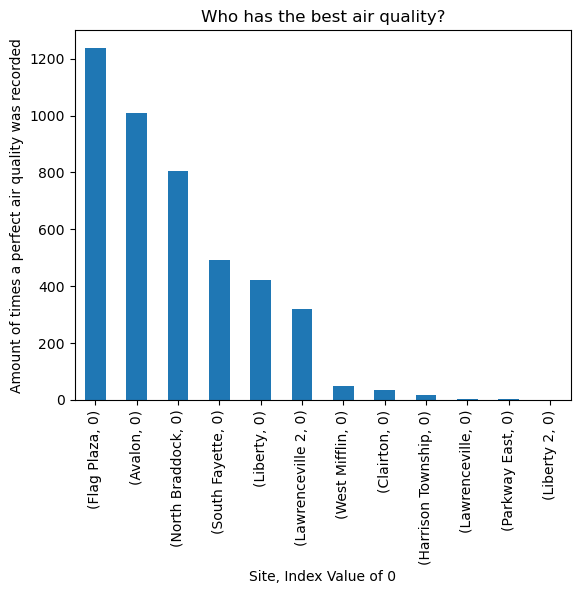

In [8]:
site_counts.plot(kind = 'bar')
plt.xlabel('Site, Index Value of 0')
plt.ylabel('Amount of times a perfect air quality was recorded')
plt.title('Who has the best air quality?')
plt.show()

### This graph shows that Flag Plaza, located in the neighborhood Bedford Dwellings, has the BEST neighborhood for consistent perfect air quality!

# Education

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Load dataset
url = "https://data.wprdc.org/datastore/dump/cbf270fd-891e-49bb-98fb-d6d52c260847"
enroll = pd.read_csv(url)

# Clean whitespace around neighborhood names
enroll["neighborhood"] = enroll["neighborhood"].astype(str).str.strip()

# Keep only useful columns
edu = enroll[["neighborhood", "total_students_enrolled"]].copy()

# Convert to numeric 
edu["total_students_enrolled"] = pd.to_numeric(
    edu["total_students_enrolled"],
    errors="coerce"
)

# Drop empty rows that truly have no enrollment data
edu = edu.dropna(subset=["total_students_enrolled"])

edu.head(10)


,neighborhood,total_students_enrolled
6,Bedford Dwellings,12.0
7,Beechview,44.0
9,Bloomfield,21.0
12,Brighton Heights,32.0
13,Brookline,57.0
15,Carrick,64.0
17,Central Northside,16.0
21,Crafton Heights,36.0
22,Crawford-Roberts,17.0
26,East Hills,44.0


Education Access Score
Here I'll find the Education Access Score:

Total number of students enrolled in public schools in each neighborhood.

This tells us which neighborhoods have the strongest education presence.

In [4]:
edu_metric = (
    edu.groupby("neighborhood")["total_students_enrolled"]
    .sum()
    .reset_index()
    .sort_values("total_students_enrolled", ascending=False)
)

edu_metric.head(10)


,neighborhood,total_students_enrolled
14,Carrick,1276.0
12,Brookline,1169.0
6,Beechview,794.0
62,Sheraden,694.0
69,Squirrel Hill South,679.0
38,Knoxville,616.0
11,Brighton Heights,598.0
35,Homewood North,589.0
23,East Hills,569.0
33,Hazelwood,567.0


### Top 15 Neighborhoods by Student Enrollment

This bar chart shows which neighborhoods have the highest student populations.


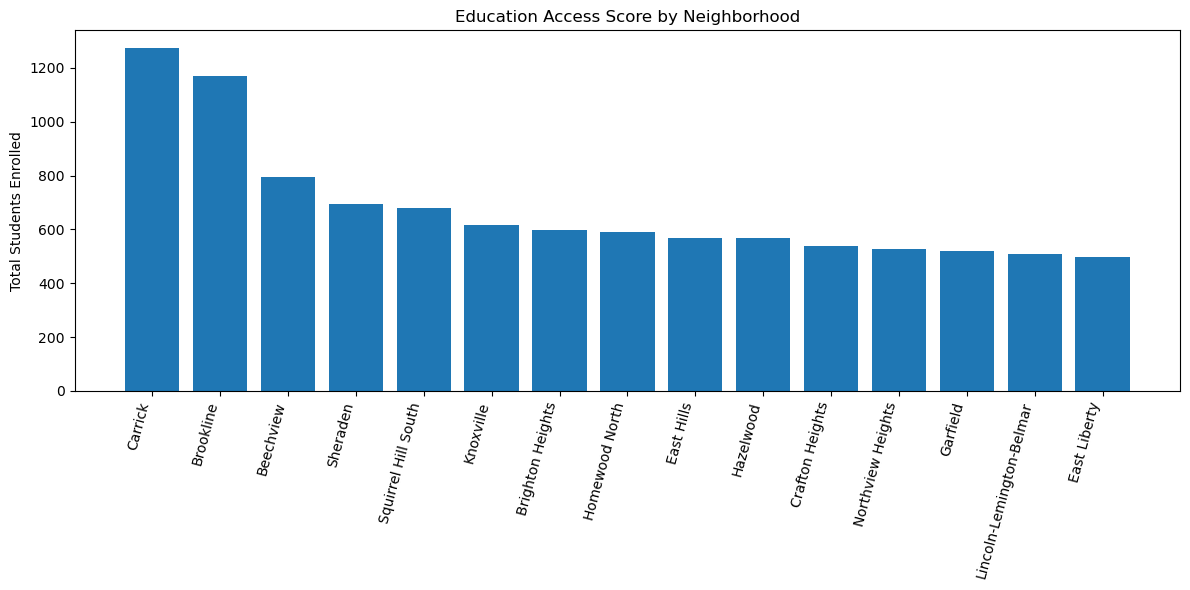

In [5]:
top15 = edu_metric.head(15)

plt.figure(figsize=(12, 6))
plt.bar(top15["neighborhood"], top15["total_students_enrolled"])
plt.ylabel("Total Students Enrolled")
plt.xticks(rotation=75, ha="right")
plt.title("Education Access Score by Neighborhood")
plt.tight_layout()
plt.show()


### Identifying the Best Neighborhood by the Education Metric

The neighborhood with the highest total student enrollment.


In [6]:
best_neighborhood = edu_metric.iloc[0]
best_neighborhood


neighborhood               Carrick
total_students_enrolled     1276.0
Name: 14, dtype: object

### According to the Education Access Score, the best neighborhood for education is: Carrick with 1276 students enrolled.

# Arrest rate

In [8]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

In [9]:
URL = "https://data.wprdc.org/datastore/dump/e03a89dd-134a-4ee8-a2bd-62c40aeebc6f"
arrest = pd.read_csv(URL)
arrest.head(88334)

,_id,PK,CCR,AGE,GENDER,RACE,ARRESTTIME,ARRESTLOCATION,OFFENSES,INCIDENTLOCATION,INCIDENTNEIGHBORHOOD,INCIDENTZONE,INCIDENTTRACT,COUNCIL_DISTRICT,PUBLIC_WORKS_DIVISION,X,Y
0,1,1975272,16158872,42.0,F,B,2016-08-24T12:20:00,"4700 Block Centre AV Pittsburgh, PA 15213",3929 Retail Theft.,"4700 Block Centre AV Pittsburgh, PA 15213",Bloomfield,5,804.0,8.0,2.0,-79.949277,40.452551
1,2,1974456,16144120,31.0,M,W,2016-08-03T14:55:00,"4200 Block Steubenville PKE Pittsburgh, PA 15205",13(a)(16) Possession of Controlled Substance,"4200 Block Steubenville PKE Pittsburgh, PA 15205",Outside City,OSC,5599.0,NaN,NaN,-80.088018,40.440136
2,3,1974466,16144165,63.0,F,B,2016-08-03T16:45:00,"900 Block Freeport RD Fox Chapel, PA 15238",3929 Retail Theft.,"900 Block Freeport RD Fox Chapel, PA 15238",Westwood,5,2811.0,9.0,2.0,-79.891803,40.486625
3,4,1974550,16145257,25.0,F,W,2016-08-05T02:36:00,"Foreland ST & Cedar AV Pittsburgh, PA 15212",5503 Disorderly Conduct. / 5505 Public Drunken...,"Foreland ST & Cedar AV Pittsburgh, PA 15212",East Allegheny,1,2304.0,1.0,1.0,-80.001939,40.454080
4,5,1974596,16145962,25.0,M,B,2016-08-06T02:00:00,"900 Block Woodlow ST Pittsburgh, PA 15205",2702 Aggravated Assault. / 2705 Recklessy Enda...,"900 Block Woodlow ST Pittsburgh, PA 15205",Crafton Heights,5,2814.0,2.0,5.0,-80.052204,40.445900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66480,88276,2064629,23140205,18.0,M,B,2023-11-04T00:49:00,"6600 Block Frankstown AV Pittsburgh, PA 15206",2702 Aggravated Assault. / 2705 Recklessy Enda...,"N Murtland ST Pittsburgh, PA 15208",Homewood North,3,1302.0,NaN,NaN,NaN,NaN
66481,88277,2064630,23146375,32.0,M,B,2023-09-14T23:44:00,"1000 Block Airport BL Pittsburgh, PA 15231",9501 Bench Warrant,"1000 Block Airport BL Pittsburgh, PA 15231",Outside City,OSC,5599.0,NaN,NaN,-80.255272,40.496059
66482,88300,2064640,22025579,58.0,F,B,2022-02-19T20:40:00,"2100 Block BROWNSVILLE RD PITTSBURGH, PA 15210",2701 Simple Assault. / 2706 Terroristic Threat...,"2100 Block Brownsville RD Pittsburgh, PA 15210",Carrick,3,2902.0,4.0,3.0,-79.986524,40.393200
66483,88333,2064660,14251296,26.0,F,B,2014-12-27T04:30:00,"2000 Block Eggers ST Pittsburgh, PA 15212",2701 Simple Assault. / 3304 Criminal Mischief....,"2000 Block Eggers ST Pittsburgh, PA 15212",Troy Hill,1,2406.0,NaN,NaN,NaN,NaN


In [10]:
arrest.groupby("INCIDENTNEIGHBORHOOD").count().loc[:,"OFFENSES"][:88334]

INCIDENTNEIGHBORHOOD
Allegheny Center       1244
Allegheny West          130
Allentown               947
Arlington               312
Arlington Heights       155
                       ... 
Upper Lawrenceville     189
West End                290
West Oakland            325
Westwood                226
Windgap                 124
Name: OFFENSES, Length: 98, dtype: int64

In [11]:
arrest_series = arrest.groupby("INCIDENTNEIGHBORHOOD").count().loc[:,"OFFENSES"].sort_values(ascending=False)
arrest_series[:40]

INCIDENTNEIGHBORHOOD
Central Business District    4440
South Side Flats             3497
Carrick                      2352
East Allegheny               2216
Homewood South               2089
Homewood North               1969
East Liberty                 1889
Marshall-Shadeland           1516
Bluff                        1502
Mount Washington             1434
Hazelwood                    1396
Brookline                    1390
Lincoln-Lemington-Belmar     1362
Knoxville                    1336
Sheraden                     1285
Allegheny Center             1244
Beechview                    1201
East Hills                   1194
Brighton Heights             1114
Perry South                  1057
Bloomfield                    984
Shadyside                     971
Allentown                     947
Middle Hill                   932
Larimer                       879
Central North Side            853
Crawford-Roberts              839
North Shore                   814
Squirrel Hill South        

In [12]:
arrest_series[:50].plot.bar()

<Axes: xlabel='INCIDENTNEIGHBORHOOD'>

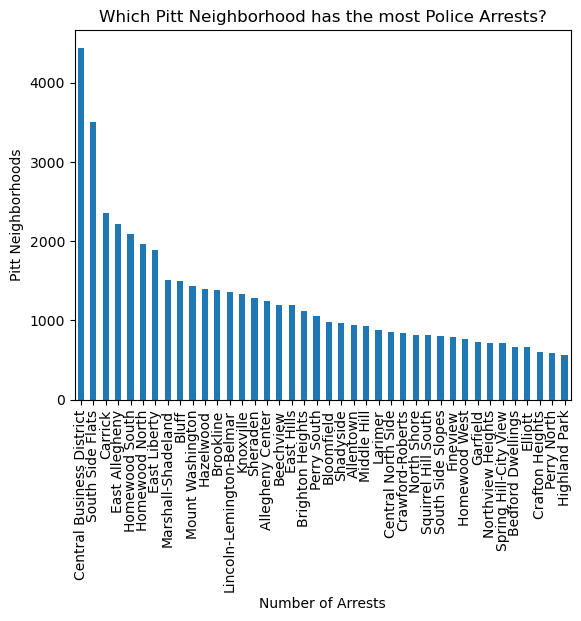

In [13]:
arrest_series[:40].plot(kind = 'bar')
plt.xlabel('Number of Arrests')
plt.ylabel('Pitt Neighborhoods')
plt.title('Which Pitt Neighborhood has the most Police Arrests?')
plt.show(arrest_series.plot)

## Top 40 neighborhoods with the LEAST arrests

In [18]:
arrest_series2 = arrest.groupby("INCIDENTNEIGHBORHOOD").count().loc[:,"OFFENSES"].sort_values(ascending=True)
arrest_series2[:40]

INCIDENTNEIGHBORHOOD
Mt. Oliver Neighborhood          2
Troy Hill-Herrs Island           6
Mt. Oliver Boro                 18
Central Northside               23
Ridgemont                       37
Regent Square                   37
New Homestead                   39
Swisshelm Park                  43
Chartiers City                  46
East Carnegie                   48
St. Clair                       55
Outside County                  57
Outside State                   67
Summer Hill                     76
Oakwood                         82
Golden Triangle/Civic Arena     83
Hays                           120
Mount Oliver                   124
Windgap                        124
Fairywood                      127
Allegheny West                 130
Arlington Heights              155
Polish Hill                    166
Glen Hazel                     169
Friendship                     174
Morningside                    188
Upper Lawrenceville            189
Duquesne Heights               191

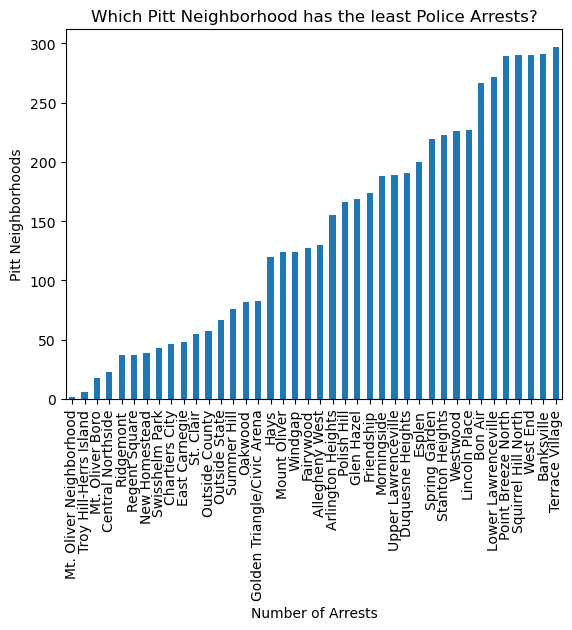

In [19]:
arrest_series2[:40].plot(kind = 'bar')
plt.xlabel('Number of Arrests')
plt.ylabel('Pitt Neighborhoods')
plt.title('Which Pitt Neighborhood has the least Police Arrests?')
plt.show(arrest_series2.plot)

### Conclusion: Mt. Oliver Neighborhood is the safest out of all Pitt neighborhoods, while Central Business District is the least safe.